# 1.6 最近傍法（2/2）: 探索アルゴリズム・最近傍重心・Transformer・NCA

**原典**: scikit-learn User Guide [1.6. Nearest Neighbors](https://scikit-learn.org/stable/modules/neighbors.html)（v1.9.1）の 1.6.4〜1.6.7

| | |
|---|---|
| **このノートで分かるようになること** | ・総当たり、KD Tree、Ball Tree が、どうやって近傍を探しているかを図で説明できる<br>・サンプル数・次元・$k$・データの構造によって、どの探索方法が速いかを実測で確かめ、`algorithm="auto"` の選び方を説明できる<br>・最近傍重心法（`NearestCentroid`）と、その縮小版の仕組みが分かる<br>・近傍グラフを前もって計算して使い回す方法（`KNeighborsTransformer`）が分かる<br>・NCA が「k 近傍法がうまくいく距離」を学習する方法であることを、図と言葉で説明できる（式は数式編） |
| **前提** | [1.6 最近傍法（1/2）](./06_neighbors_1_knn.ipynb)、[1.2 LDA と QDA](./02_lda_qda.ipynb)（NCA との比較） |
| **目安時間** | 90〜120 分 |

### 🗺️ 3 行でいうと

1. 近傍探索を速くする**木構造**（KD Tree / Ball Tree）は、「この箱（球）の中の点はどれも遠い」と分かれば、中の点との距離を計算せずに済ませる索引。低次元では速いが、高次元では総当たりに負ける。
2. **最近傍重心法**は、クラスごとの「重心」だけを覚えて、いちばん近い重心のクラスに分類する、最も単純な分類器。
3. **NCA** は、「k 近傍法がうまくいく距離（ものさし）」をデータから学習する。

> 📐 **数式について**: 本文は**数式なしで読める**ように書いています（中学修了程度の数学で足ります）。式で確かめたい人は [数式編](./math/06_neighbors_2_algorithms_nca_math.md) へ。必要な数学の道具は [数学の準備](../00_math_primer.md)、用語は [用語集](../glossary.md) にまとめています。

### このノートの読み方

| 記号 | 意味 |
|---|---|
| 📖 **ガイドの解説** | 公式ガイドの内容を日本語で説明したもの |
| 💡 **補足** | 初学者向けに、ガイドにない前提知識・直感・たとえ話を足したもの |
| 📚 **用語** / 🔢 **数式を読む** | 初出の用語の説明 /（数式編の中で）数式の記号を 1 つずつ説明し、日本語で読み下したもの |
| 🎯 **なぜ使うのか** / 🏭 **利用例** / 🕰️ **歴史** | 手法が使われる理由・実際の応用・生まれた経緯（参考情報） |
| 🧪 **やってみよう** / 📈 **学習したモデルを見る** / 👀 **結果の読み方** | コードで確かめる / 学習したモデルを図で確かめる / 出力のどこを見ればよいか |
| ⚠️ **つまずきポイント** | 実際に動かして分かった落とし穴（ガイドに書かれていないものを含む） |
| 🏢 **実務での選ばれ方** | 実際の業務で、その手法が選ばれる場面・選ばれない場面・よく組み合わせる手法 |
| 💬 **ことばで言うと** / 📐 **数式編** | 式の意味を言葉だけで説明したもの / 式・記号の表・導き方をまとめた別ファイルへのリンク |

> ⚠️ このノートには**実行時間を測る**実験があります。時間の値は、実行するコンピュータによって変わります。

### 目次

1. 1.6.4 最近傍のアルゴリズム（総当たり / KD Tree / Ball Tree / 選び方 / `leaf_size`）
2. 1.6.5 最近傍重心法（縮小版を含む）
3. 1.6.6 最近傍の Transformer
4. 1.6.7 近傍成分分析（NCA）
5. まとめ・確認クイズ

## セットアップ

実行済みの出力つきで保存しています。手元で動かす場合は、上から順に実行してください。

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # グラフで日本語を表示するため

from sklearn import linear_model as lm

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.figsize": (6, 3.6), "figure.dpi": 80, "axes.grid": True})
rng = np.random.RandomState(0)  # 乱数の種を固定（同じ結果を再現するため）

import time
import tempfile
from matplotlib.patches import Rectangle, Circle
from sklearn import neighbors as nbr
from sklearn.datasets import load_iris, load_digits, make_moons, make_blobs, make_classification, make_regression
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import Isomap
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

def best_time(func, repeat=3):
    times = []
    for _ in range(repeat):
        t = time.perf_counter(); func(); times.append(time.perf_counter() - t)
    return min(times)

def plot_regions(ax, model, X, y, title, h=0.02):
    # 学習したモデルの決定領域（背景の色）とデータ点を描く（多クラス用）
    x0, x1 = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y0, y1 = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x0, x1, h), np.arange(y0, y1, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="viridis", levels=np.arange(-0.5, len(np.unique(y)) + 0.5))
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k", s=15)
    ax.set_title(title, fontsize=9); ax.grid(False)

---
## 1. 最近傍のアルゴリズム（1.6.4 Nearest Neighbor Algorithms）

💡 1/2 で、k 近傍法の中身は「距離を全部計算して、近い順に並べる」だけだと確かめました。この節は、その「全部計算する」をどう**サボるか**の話です。たとえるなら、図書館で本を探すとき、全部の棚を端から見る（総当たり）か、分類番号の案内板をたどって目当ての棚に直行する（木構造の索引）か、の違いです。

### 1.6.4.1 総当たり（Brute Force）

#### 📖 ガイドの解説

最近傍の高速な計算は、機械学習の活発な研究分野です。最も素朴な近傍探索の実装は、データのすべての点の組の距離を総当たりで計算するものです。$D$ 次元の $N$ 個のサンプルに対して、この方法は $O[D N^2]$ で増えます。効率よく実装された総当たりの近傍探索は、小さなデータではとても競争力があります。しかし、サンプル数 $N$ が増えると、総当たりはすぐに現実的でなくなります。`sklearn.neighbors` のクラスでは、総当たりの探索は `algorithm='brute'` で指定し、`sklearn.metrics.pairwise` の関数で計算されます。

### 💬 計算量をことばで

総当たりでは、n 個の点のすべての組（約 n × n 組）について、特徴の数だけ差を計算するので、計算量は「特徴の数 × サンプル数の 2 乗」に比例します（データが 10 倍なら約 100 倍）。**問い合わせ 1 点あたり**なら、n 個との距離を計算するので「特徴の数 × サンプル数」に比例します（[数学の準備「計算量の記号」](../00_math_primer.md#bigO)）。

> 📐 式で確かめたい人へ: [数式編「総当たりの計算量」](./math/06_neighbors_2_algorithms_nca_math.md#complexity)

### 1.6.4.2 KD Tree

#### 📖 ガイドの解説

総当たりの計算の非効率さに対処するため、さまざまな**木構造**のデータ構造が考案されてきました。一般にこれらの構造は、サンプルについての**まとめた距離の情報**を効率よく記録して、必要な距離の計算の回数を減らそうとします。基本の考え方は、「点 $A$ が点 $B$ から非常に遠く、点 $B$ が点 $C$ に非常に近いなら、点 $A$ と点 $C$ も非常に遠いと分かる。**実際に距離を計算しなくても**」というものです。こうして、最近傍探索の計算コストを $O[D N \log(N)]$ かそれ以下に減らせます。大きな $N$ では、総当たりから大きく改善します。

このまとめた情報を活かす初期の方法が **KD tree**（K 次元の木、K-dimensional tree の略）のデータ構造です。2 次元の **Quad-tree（四分木）**や 3 次元の **Oct-tree（八分木）**を、任意の次元に一般化したものです。KD tree は**二分木**の構造で、データの**軸に沿って**パラメータの空間を再帰的に分割し、入れ子になった**軸に平行な領域**を作って、そこにデータ点を振り分けます。

KD tree の構築はとても速いです。分割はデータの軸に沿ってだけ行うので、$D$ 次元の距離を計算する必要がないからです。いったん構築すれば、問い合わせ点の最近傍は、$O[\log(N)]$ 回の距離の計算だけで決められます。KD tree の方法は、低次元（$D < 20$）の近傍探索ではとても速いですが、$D$ がとても大きくなると非効率になります。これも、いわゆる「次元の呪い」の現れの 1 つです。scikit-learn では、KD tree の近傍探索は `algorithm='kd_tree'` で指定し、`KDTree` クラスで計算されます。

> 📚 **用語**
> - **二分木（binary tree）** — 各ノード（節）が最大 2 つの子を持つ木構造。KD tree では「ある軸のある値より小さい側 / 大きい側」の 2 つに分ける。
> - **Quad-tree / Oct-tree** — 2 次元の平面を 4 つの正方形に、3 次元の空間を 8 つの立方体に、再帰的に分ける木。地図アプリやゲームの当たり判定などで使われる。
> - **葉（leaf）** — それ以上分けないノード。scikit-learn では、葉の中の点の数が `leaf_size` 程度になるまで分割する。
> - **$\log(N)$** — $N$ を何回半分にすると 1 になるか、の回数（底 2 の場合）。100 万でも約 20。二分木の深さはだいたい $\log_2 N$ になる。

🕰️ **歴史（参考情報）**: KD tree は、1975 年にジョン・ベントリー（Jon Bentley、当時スタンフォード大学の学生）が *Communications of the ACM* の論文「Multidimensional binary search trees used for associative searching」で発表しました。データベースの多次元の範囲検索のための構造で、今も地理情報システムやコンピュータグラフィックスで広く使われています。

#### 📈 学習した索引を見る: KD Tree は空間をどう分けているか

`KDTree` の `get_arrays()` で、木の各ノードが受け持つ点の範囲（各軸の最小値と最大値の箱）を取り出せます。2 次元のデータ 400 点で、木の浅いところから深いところへ、ノードの箱を描きます。

ノードの数: 63 / node_bounds の形: (2, 63, 2) （最小と最大, ノード, 次元）


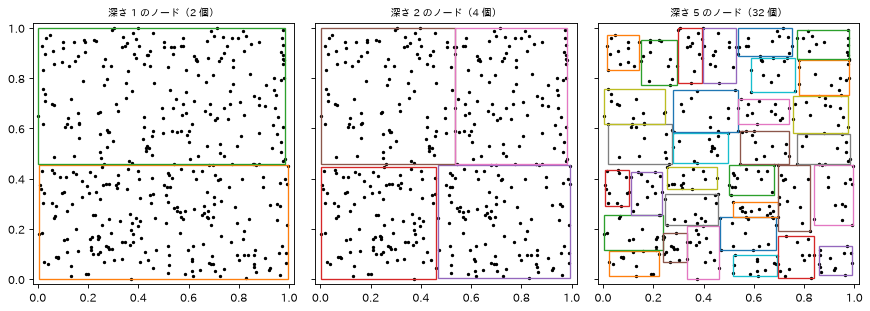

In [2]:
Xk = np.random.RandomState(0).rand(400, 2)
kdt = nbr.KDTree(Xk, leaf_size=10)
data, idx_array, node_data, node_bounds = kdt.get_arrays()
print("ノードの数:", len(node_data), "/ node_bounds の形:", node_bounds.shape, "（最小と最大, ノード, 次元）")
level_of = np.floor(np.log2(np.arange(len(node_data)) + 1)).astype(int)   # ノード i の深さ（根が 0）
fig, axes = plt.subplots(1, 3, figsize=(11, 3.7), sharey=True)
for ax, level in zip(axes, [1, 2, level_of.max()]):
    ax.scatter(Xk[:, 0], Xk[:, 1], s=4, c="k")
    for i in np.where(level_of == level)[0]:
        lo, hi = node_bounds[0, i], node_bounds[1, i]
        ax.add_patch(Rectangle(lo, *(hi - lo), fill=False, ec=plt.cm.tab10(i % 10), lw=1.2))
    ax.set_title(f"深さ {level} のノード（{(level_of == level).sum()} 個）", fontsize=9)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02); ax.set_aspect("equal"); ax.grid(False)
plt.tight_layout(); plt.show()

### 👀 結果の読み方

- **深さ 1**: 根（全体）を 1 本の線で 2 つに分けた箱が 2 つあります。どちらかの軸に平行な線で、点の数がほぼ半分ずつになるように分けています。
- **深さ 2**: それぞれをさらに 2 つに分け、4 つの箱になります。
- **一番深いところ（葉）**: 小さな箱がたくさん並び、それぞれに `leaf_size` 程度の点が入っています。

箱の辺はすべて**軸に平行**です。問い合わせ点から見て「この箱の中の点は、どれも今の候補より遠い」と、箱の位置だけで分かれば、その箱の中の点との距離は**計算しないで済みます**（枝刈り）。これがガイドの「まとめた距離の情報」の正体です。

> 💡 scikit-learn の `KDTree` が持つ箱は、分割した線そのものではなく、**ノードに入っている点をぴったり囲む箱**です。そのため、隣り合う箱の間にすき間が見えることがあります。

### 1.6.4.3 Ball Tree

#### 📖 ガイドの解説

高次元での KD tree の非効率さに対処するため、**ball tree** のデータ構造が開発されました。KD tree がデータを直交座標の軸に沿って分割するのに対し、ball tree はデータを**入れ子になった超球**の列で分割します。そのため木の構築は KD tree より高くつきますが、非常に高い次元でも、**構造をもったデータ**に対しては非常に効率のよいデータ構造になります。

ball tree は、データを再帰的にノードに分割します。各ノードは**中心** $C$ と**半径** $r$ で定義され、ノードの各点は $r$ と $C$ で決まる超球の中にあります。近傍探索の候補の点の数は、**三角不等式**を使って減らします。

この仕組みでは、テスト点とノードの中心との距離を 1 回計算するだけで、ノード内のすべての点への距離の**下限と上限**が決まります。ball tree のノードは球の形をしているので、高次元では KD tree を上回る性能を出せますが、実際の性能は学習データの構造に大きく依存します。scikit-learn では、ball tree による近傍探索は `algorithm='ball_tree'` で指定し、`BallTree` クラスで計算されます。`BallTree` クラスを直接使うこともできます。

> 📚 **用語**: **超球（hyper-sphere）** — 3 次元より高い次元での「球」。中心から距離 $r$ 以内の点の集まり。2 次元なら円、3 次元なら球。

### 💬 三角不等式で、球の中の点をまとめて評価する（ことばで）

**三角不等式**は「寄り道すると、まっすぐ行くより遠くなる」という性質です。これを使うと、問い合わせ点と球の**中心までの距離を 1 回測るだけ**で、球の中の**どの点も**「中心までの距離 − 半径」より近くはなく、「中心までの距離 + 半径」より遠くはない、と分かります。だから「中心までの距離 − 半径」が今の k 番目の候補の距離より大きければ、その球の中の点は 1 つも計算せずに捨てられます（**枝刈り**）。

🔄 **たとえ**: 遠くの町（球）の中心まで 10 km、町の半径が 3 km なら、その町のどの家も 7 km より近くにはありません。いまいちばん近い店が 5 km 先にあるなら、その町の店を 1 軒ずつ調べる必要はありません。

> 📐 式で確かめたい人へ: [数式編「三角不等式による下限と上限」](./math/06_neighbors_2_algorithms_nca_math.md#triangle)

> 💡 この仕組みは、三角不等式さえ成り立てば、**どんな距離でも**使えます。KD tree の「軸に平行な箱」は座標軸に沿った距離（ミンコフスキー系）でしか使えないので、1/2 で見たとおり、`BallTree.valid_metrics` のほうがずっと多いのです。

🕰️ **歴史（参考情報）**: ball tree は、スティーブン・オモハンドロ（Stephen Omohundro）が 1989 年の技術報告「Five Balltree Construction Algorithms」（International Computer Science Institute）で、その構築の方法を体系的にまとめたことで知られます。

#### 📈 学習した索引を見る: Ball Tree の球

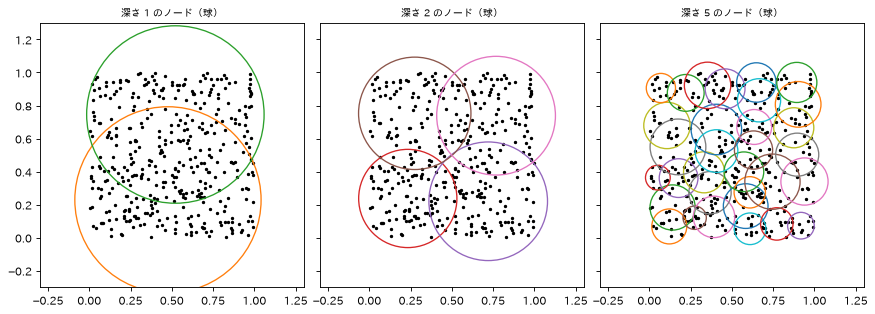

In [3]:
blt = nbr.BallTree(Xk, leaf_size=10)
_, _, bnode_data, bnode_bounds = blt.get_arrays()
fig, axes = plt.subplots(1, 3, figsize=(11, 3.7), sharey=True)
for ax, level in zip(axes, [1, 2, level_of.max()]):
    ax.scatter(Xk[:, 0], Xk[:, 1], s=4, c="k")
    for i in np.where(level_of == level)[0]:
        center, radius = bnode_bounds[0, i], bnode_data[i]["radius"]
        ax.add_patch(Circle(center, radius, fill=False, ec=plt.cm.tab10(i % 10), lw=1.2))
    ax.set_title(f"深さ {level} のノード（球）", fontsize=9)
    ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.3); ax.set_aspect("equal"); ax.grid(False)
plt.tight_layout(); plt.show()

### 👀 結果の読み方

- ノードは**円（2 次元の球）**で、中に入っている点をすべて囲んでいます。KD tree の箱と違い、**球どうしは重なってもかまいません**。
- 深くなるほど球は小さくなり、葉では `leaf_size` 程度の点を囲む小さな球になります。
- 球は軸の向きに縛られないので、データが斜めに伸びていたり、曲がった形（多様体）に沿っていたりしても、その形に合わせて囲めます。これが「構造をもったデータで効率がよい」理由です。

### 🧪 やってみよう: 1 回の問い合わせで、何回距離を計算しているか

`KDTree` / `BallTree` の `get_n_calls()` は、距離の関数を呼んだ回数を返します（Ball Tree では、点との距離に加えて、ノードの中心との距離も数えます）。3 次元の一様乱数のデータで、サンプル数 $N$ を変えて、問い合わせ 1 点あたりの回数を比べます。総当たりなら、ちょうど $N$ 回です。

In [4]:
rs = np.random.RandomState(0)
rows = []
for N in [1_000, 10_000, 100_000, 1_000_000]:
    P = rs.rand(N, 3); Q = rs.rand(200, 3)
    row = {"N": f"{N:,}", "総当たり": N}
    for name, Tree in [("KD Tree", nbr.KDTree), ("Ball Tree", nbr.BallTree)]:
        tree = Tree(P); tree.reset_n_calls(); tree.query(Q, k=1)
        row[name] = tree.get_n_calls() / len(Q)
    rows.append(row)
pd.DataFrame(rows).set_index("N").round(1)

,総当たり,KD Tree,Ball Tree
N,,,
"1,000",1000,96.6,229.4
"10,000",10000,130.9,499.7
"100,000",100000,93.0,597.6
"1,000,000",1000000,123.0,1079.0


### 👀 結果の読み方

- 総当たりは $N$ に比例して増え、100 万件では 1 回の問い合わせで 100 万回の距離の計算が必要です。
- KD Tree は、$N$ が 1,000 から 100 万に 1,000 倍になっても、**100 回前後のまま**ほとんど増えません。数十回は、葉の中の点（`leaf_size=30` 程度）と、その近くの葉を総当たりで調べる分です。ガイドの「$O[\log(N)]$ 回の距離の計算」の効果で、$\log$ の増え方はとてもゆっくりなので、この範囲では一定に近く見えます。
- Ball Tree は、ノードの中心との距離も数えるぶん KD Tree より多いですが、それでも 100 万件で約 1,000 回と、総当たりの 1,000 分の 1 です。

### 📖 近傍探索のアルゴリズムの選び方

与えられたデータに最適なアルゴリズムを選ぶのは複雑で、いくつもの要因に依存します。

**① サンプル数 $N$（`n_samples`）と次元 $D$（`n_features`）**

| アルゴリズム | 問い合わせの時間 |
|---|---|
| 総当たり | サンプル数に比例して増える（$O[D N]$） |
| Ball tree | サンプル数が増えても、ゆっくりしか増えない（およそ $O[D \log(N)]$） |
| KD tree | $D$ による変化を正確に表すのは難しい。小さな $D$（20 程度未満）では約 $O[D \log(N)]$ で、とても効率がよい。$D$ が大きいと、ほぼ $O[DN]$ まで増え、木構造のオーバーヘッドのために総当たりより遅くなることがある |

小さなデータ（$N$ がおよそ 30 未満）では、$\log(N)$ は $N$ とあまり変わらず、総当たりのほうが木より効率がよいことがあります。`KDTree` と `BallTree` は、**葉のサイズ（leaf size）**の引数でこれに対処しています。これは、問い合わせが総当たりに切り替わるサンプル数を決めるもので、小さな $N$ では総当たりに近い効率になります。

**② データの構造: データの内在的な次元、データのまばらさ**

**内在的な次元**とは、データが乗っている**多様体**の次元 $d \le D$ のことです。多様体は、パラメータの空間に線形にも非線形にも埋め込まれていることがあります。**まばらさ（sparsity）**とは、データがパラメータの空間をどの程度埋めているかを指します（「疎な」行列の意味とは区別してください。データの行列に 0 の要素が 1 つもなくても、この意味では「まばら」なことがあります）。

- 総当たりの問い合わせ時間は、データの構造に影響されません。
- Ball tree と KD tree の問い合わせ時間は、データの構造に大きく影響されます。一般に、内在的な次元が小さい、まばらなデータほど、問い合わせは速くなります。KD tree の内部表現は座標軸にそろっているので、任意の構造のデータに対しては、一般に ball tree ほどの改善は見られません。

機械学習で使われるデータは、強い構造を持つことが多く、木構造の問い合わせに非常に向いています。

> 📚 **用語**: **多様体（manifold）/ 内在的な次元（intrinsic dimensionality）** — たとえば、3 次元の空間の中で、紙を丸めたような曲面の上にだけデータがあるなら、見かけの次元は 3 でも、データの「本当の自由度」は 2（紙の上の位置）。この曲面が多様体で、2 が内在的な次元。手書き数字の画像（64 次元）も、実際には「線の太さ、傾き、…」など少数の自由度で決まるので、内在的な次元はずっと小さいと考えられる。

**③ 問い合わせ点に対して要求する近傍の数 $k$**

- 総当たりの問い合わせ時間は、$k$ の値にほとんど影響されません。
- Ball tree と KD tree の問い合わせ時間は、$k$ が増えると遅くなります。理由は 2 つあります。1 つ目に、$k$ が大きいと、パラメータの空間のより広い部分を探す必要があります。2 つ目に、$k > 1$ では、木をたどりながら結果を内部の**キュー**に並べておく必要があります。

$k$ が $N$ に比べて大きくなると、木の問い合わせで枝を刈る能力が下がります。この場合、総当たりの問い合わせのほうが効率的になりえます。

**④ 問い合わせ点の数**: ball tree と KD tree はどちらも構築の段階が必要です。この構築のコストは、多くの問い合わせで分け合えば無視できます。しかし、問い合わせの数が少ない場合は、構築が全体のコストのかなりの部分を占めることがあります。問い合わせ点がごく少ないなら、総当たりのほうが木の方法よりよいです。

### 🧪 やってみよう ①: サンプル数 $N$ と時間（3 次元、問い合わせ 2,000 点、$k = 5$、構築を含む）

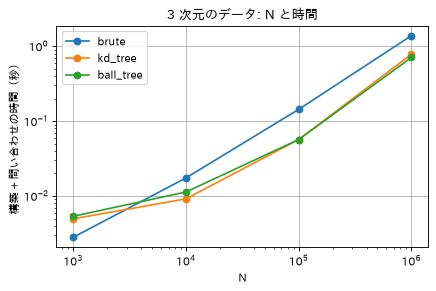

,brute,kd_tree,ball_tree
N,,,
1000,0.0028,0.0049,0.0053
10000,0.0174,0.0092,0.0113
100000,0.1436,0.0568,0.0568
1000000,1.3864,0.7821,0.7086


In [5]:
rs = np.random.RandomState(0)
algos = ["brute", "kd_tree", "ball_tree"]
rows = []
for N in [1_000, 10_000, 100_000, 1_000_000]:
    P = rs.rand(N, 3); Q = rs.rand(2000, 3)
    row = {"N": N}
    for a in algos:
        row[a] = best_time(lambda: nbr.NearestNeighbors(n_neighbors=5, algorithm=a).fit(P).kneighbors(Q), repeat=2)
    rows.append(row)
df_n = pd.DataFrame(rows).set_index("N")
df_n.plot(loglog=True, marker="o"); plt.ylabel("構築 + 問い合わせの時間（秒）"); plt.title("3 次元のデータ: N と時間"); plt.show()
df_n

👀 $N = 1{,}000$ ではどれもほぼ同じ（数ミリ秒）ですが、$N$ が大きくなるほど総当たり（`brute`）が遅れ、100 万件では木（`kd_tree`, `ball_tree`）のほうが速くなりました。ただし差は 2 倍弱です。距離の計算回数は 1,000 倍以上違ったのに、時間の差がそれほど開かないのは、総当たりが**行列の積（BLAS）**でまとめて高速に計算できるのに対し、木は 1 点ずつ枝をたどる処理で、さらに木の**構築**の時間も含まれているからです。

### 🧪 やってみよう ②: 次元 $D$ とデータの構造（$N = 20{,}000$、問い合わせ 2,000 点、$k = 5$）

2 種類のデータで比べます。

- **一様**: $D$ 次元の立方体の中に一様に散らばったデータ（内在的な次元 = $D$、構造なし）
- **構造あり**: 2 次元の一様乱数を、非線形な変換 $\sin(ZA)$ で $D$ 次元に埋め込んだデータ（見かけは $D$ 次元だが、内在的な次元は 2）

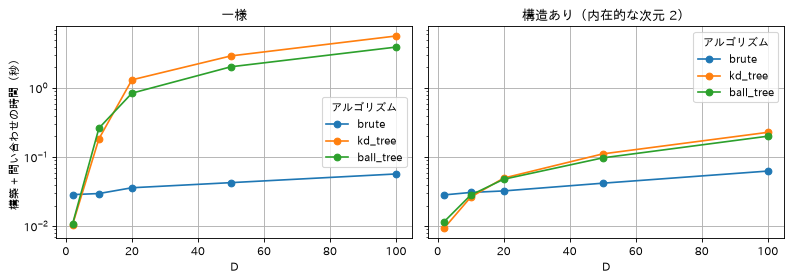

データ         一様                   構造あり（内在的な次元 2）                  
アルゴリズム   brute kd_tree ball_tree          brute kd_tree ball_tree
D                                                                
2       0.0288  0.0105    0.0108         0.0285  0.0095    0.0117
10      0.0298  0.1848    0.2639         0.0309  0.0264    0.0283
20      0.0362  1.3224    0.8479         0.0325  0.0500    0.0481
50      0.0429  2.9371    2.0443         0.0421  0.1119    0.0980
100     0.0573  5.7039    3.9401         0.0631  0.2297    0.2018

In [6]:
rs = np.random.RandomState(0)
rows = []
for D in [2, 10, 20, 50, 100]:
    U = rs.rand(22_000, D)                                       # 一様（構造なし）
    Z = rs.rand(22_000, 2); A = rs.randn(2, D); S = np.sin(Z @ A)  # 2 次元の多様体を D 次元に埋め込む
    for kind, W in [("一様", U), ("構造あり（内在的な次元 2）", S)]:
        P, Q = W[:20_000], W[20_000:]
        for a in algos:
            t = best_time(lambda: nbr.NearestNeighbors(n_neighbors=5, algorithm=a).fit(P).kneighbors(Q), repeat=2)
            rows.append({"D": D, "データ": kind, "アルゴリズム": a, "時間（秒）": t})
df_d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, kind in zip(axes, ["一様", "構造あり（内在的な次元 2）"]):
    sub = df_d[df_d["データ"] == kind].pivot(index="D", columns="アルゴリズム", values="時間（秒）")[algos]
    sub.plot(ax=ax, marker="o", logy=True, title=kind)
axes[0].set_ylabel("構築 + 問い合わせの時間（秒）"); plt.tight_layout(); plt.show()
df_d.pivot_table(index="D", columns=["データ", "アルゴリズム"], values="時間（秒）")[[("一様", a) for a in algos] + [("構造あり（内在的な次元 2）", a) for a in algos]]

### 👀 結果の読み方

- **一様なデータ（左）**: $D = 2$ では木が総当たりより速いですが、$D = 10$ ですでに逆転し、$D = 20$ 以上では木が総当たりの**数十倍遅く**なりました。ガイドの「$D$ が大きいと、木のオーバーヘッドで総当たりより遅くなることがある」がはっきり再現されています。$D$ が 20 以上では、Ball Tree のほうが KD Tree より速く、「高次元では ball tree が KD tree を上回りうる」とも合っています。
- **構造のあるデータ（右）**: 見かけの次元が同じでも、木の時間は一様なデータよりずっと短くなりました（$D = 100$ で一桁以上）。ガイドの「内在的な次元が小さいデータほど木は速い」の効果です。
- ただし、この実験の範囲では、$D = 20$ 以上になると、構造のあるデータでも総当たりが最速でした（$D = 10$ までは木が速い）。ガイドの「非常に高い次元でも ball tree が効率的になりうる」は、**木どうしの比較**や、総当たりが使いにくい状況（巨大なデータ、BLAS が使えない距離）では当てはまりますが、行列の積で速く計算できる総当たりに勝つのは簡単ではありません。

### 🧪 やってみよう ③: $k$ と問い合わせの時間（$N = 100{,}000$、3 次元、構築を除く）

In [7]:
rs = np.random.RandomState(0)
P = rs.rand(100_000, 3); Q = rs.rand(2000, 3)
fitted = {a: nbr.NearestNeighbors(algorithm=a).fit(P) for a in algos}
rows = []
for k in [1, 10, 100, 1000]:
    rows.append({"k": k, **{a: best_time(lambda: fitted[a].kneighbors(Q, n_neighbors=k), repeat=2) for a in algos}})
df_kq = pd.DataFrame(rows).set_index("k")
df_kq

,brute,kd_tree,ball_tree
k,,,
1,0.1227,0.0048,0.0112
10,0.1270,0.0098,0.0205
100,0.2193,0.0437,0.0909
1000,0.8334,0.3971,0.6070


👀 $k$ を 1 から 100 に増やすと、木の問い合わせ時間は約 8〜9 倍になりましたが、総当たりは 2 倍弱でした（どちらにしても全部の距離を計算するので、$k$ の影響は並べ替えの分だけ）。$k = 1000$ では総当たりも遅くなりますが、木との差は縮まっています。ガイドの「木の問い合わせは $k$ が大きいと遅くなる」「総当たりは $k$ にあまり影響されない」と合っています（ただし $k = 1000$ まで増やすと総当たりも数倍遅くなるので、「ほとんど影響されない」は $k$ が小さい範囲での話です）。

### 📖 `algorithm='auto'` の選び方

現在、`algorithm = 'auto'` は、次のどれかの条件が成り立つと `'brute'` を選びます。

- 入力のデータが疎（sparse）
- `metric = 'precomputed'`
- $D > 15$
- $k \ge N/2$
- `effective_metric_` が、`'kd_tree'` と `'ball_tree'` のどちらの `VALID_METRICS` のリストにもない

それ以外の場合は、`'kd_tree'` と `'ball_tree'` のうち、`effective_metric_` を `VALID_METRICS` のリストに持つ**最初の**ものを選びます。この経験則は、次の前提に基づいています。

- 問い合わせ点の数が、少なくとも学習の点の数と同じ程度ある
- `leaf_size` が既定値の 30 に近い
- $D > 15$ のときは、データの内在的な次元は一般に木の方法には高すぎる

#### 🧪 本当にそう選ばれるか確かめる

> ⚠️ `_fit_method` は、学習後に実際に選ばれたアルゴリズムを持つ**非公開の属性**（名前が `_` で始まる）です。確認のためだけに使い、普段のコードでは頼らないでください。

In [8]:
from scipy import sparse
rs = np.random.RandomState(0)
cases = [
    ("D = 3",                         dict(), rs.rand(100, 3)),
    ("D = 15",                        dict(), rs.rand(100, 15)),
    ("D = 16（> 15）",                 dict(), rs.rand(100, 16)),
    ("疎な行列（D = 3）",               dict(), sparse.random(100, 3, density=0.5, format="csr", random_state=0)),
    ("k = 5, N = 12（k < N/2）",        dict(n_neighbors=5), rs.rand(12, 3)),
    ("k = 5, N = 10（k ≥ N/2）",        dict(n_neighbors=5), rs.rand(10, 3)),
    ("metric='cosine'",               dict(metric="cosine"), rs.rand(100, 3)),
    ("metric='haversine'（D = 2）",    dict(metric="haversine"), rs.rand(100, 2)),
]
pd.DataFrame([{"条件": name, "選ばれたアルゴリズム": nbr.NearestNeighbors(**kw).fit(Xc)._fit_method} for name, kw, Xc in cases]).set_index("条件")

,選ばれたアルゴリズム
条件,
D = 3,kd_tree
D = 15,kd_tree
D = 16（> 15）,brute
疎な行列（D = 3）,brute
"k = 5, N = 12（k < N/2）",kd_tree
"k = 5, N = 10（k ≥ N/2）",brute
metric='cosine',brute
metric='haversine'（D = 2）,ball_tree


👀 ガイドの規則どおりです。$D = 15$ では `kd_tree`、$D = 16$ で `brute` に切り替わります。`cosine` は KD Tree も Ball Tree も対応していないので `brute`、`haversine`（地球上の 2 点の距離）は KD Tree が対応しておらず Ball Tree が対応しているので `ball_tree` になりました。

> 💡 実験 ② の結果と合わせると、`auto` の規則（$D > 15$ なら総当たり）は、構造のないデータでは妥当です。構造のある高次元データでは木が有利な場合もありえるので、大きなデータでは `algorithm` を変えて時間を測ってみる価値があります。

### 📖 `leaf_size` の効果

上で述べたとおり、小さなサンプルでは、総当たりの探索のほうが木の問い合わせより効率的なことがあります。ball tree と KD tree では、**葉のノードの中では内部で総当たりの探索に切り替える**ことで、これに対応しています。この切り替えのレベルは、引数 `leaf_size` で指定できます。この引数の選択には、多くの影響があります。

| 観点 | 影響 |
|---|---|
| 構築の時間 | `leaf_size` が大きいほど、作るノードが少なくなるので、木の構築が速くなる |
| 問い合わせの時間 | 大きすぎても小さすぎても、最適でない問い合わせのコストになる。1 に近いと、ノードをたどるオーバーヘッドで問い合わせが大きく遅くなる。学習データの大きさに近いと、問い合わせは実質的に総当たりになる。両者のよい妥協点が、既定値の `leaf_size = 30` |
| メモリ | `leaf_size` が大きくなると、木構造を保存するのに必要なメモリが減る。これは特に ball tree で重要で、ノードごとに $D$ 次元の中心を保存する。`BallTree` に必要な記憶領域は、学習データの大きさのおよそ `1 / leaf_size` 倍 |

`leaf_size` は、総当たりの問い合わせでは使われません。

#### 🧪 確かめる（$N = 200{,}000$、3 次元、`KDTree`、問い合わせ 5,000 点、$k = 5$）

In [9]:
rs = np.random.RandomState(0)
P = rs.rand(200_000, 3); Q = rs.rand(5000, 3)
rows = []
for ls in [1, 5, 30, 100, 1000, 10000]:
    build = best_time(lambda: nbr.KDTree(P, leaf_size=ls), repeat=2)
    tree = nbr.KDTree(P, leaf_size=ls)
    query = best_time(lambda: tree.query(Q, k=5), repeat=2)
    ball_centers = nbr.BallTree(P, leaf_size=ls).get_arrays()[3]
    rows.append({"leaf_size": ls, "構築（秒）": build, "問い合わせ（秒）": query, "ノードの数": len(tree.get_arrays()[2]),
                 "BallTree の中心の記憶量 ÷ データの記憶量": ball_centers.nbytes / P.nbytes})
df_leaf = pd.DataFrame(rows).set_index("leaf_size")
df_leaf

,構築（秒）,問い合わせ（秒）,ノードの数,BallTree の中心の記憶量 ÷ データの記憶量
leaf_size,,,,
1,0.1622,0.0320,262143,1.3107
5,0.1337,0.0205,65535,0.3277
30,0.1010,0.0180,8191,0.0410
100,0.0821,0.0249,2047,0.0102
1000,0.0584,0.0891,255,0.0013
10000,0.0377,0.4978,31,0.0002


### 👀 結果の読み方

- **構築の時間**は、`leaf_size` が大きいほど短くなりました（ノードの数が減るため）。
- **問い合わせの時間**は、`leaf_size = 30` 付近で最も短く、1 に近づけても、10,000 まで大きくしても遅くなる **U 字型**です。ガイドの説明どおりで、既定値 30 がよい妥協点になっています。
- **Ball Tree の中心の記憶量**は、`leaf_size = 30` でデータの数 % 程度、1 にするとデータの 1 倍以上と、`leaf_size` にほぼ反比例しています（ガイドの「およそ `1 / leaf_size` 倍」）。ノードの数は 2 のべき乗 − 1 にそろえられるので、ちょうど反比例ではありません。

### 📖 最近傍のアルゴリズムで使える距離

使える距離の一覧は、`DistanceMetric` クラスのドキュメントと、`sklearn.metrics.pairwise.PAIRWISE_DISTANCE_FUNCTIONS` に挙げられた距離を参照してください。`"cosine"` の距離は `cosine_distances` を使います。それぞれのアルゴリズムで使える距離は、`valid_metrics` 属性で得られます。

In [10]:
print(sorted(nbr.KDTree.valid_metrics))

['chebyshev', 'cityblock', 'euclidean', 'infinity', 'l1', 'l2', 'manhattan', 'minkowski', 'p']


### 🏢 実務での選ばれ方: KD Tree / Ball Tree

- ✅ **特に選ばれる場面**: 低次元（〜十数次元）で、データが多く、問い合わせも多いとき（地図の座標で「近くの店」を探す、3D 点群、物理シミュレーション）。Ball Tree は、緯度経度の距離（haversine）など特殊な距離を使いたいとき。
- ❌ **選ばれない場面**: 高次元（数十次元以上）で構造のないデータ（総当たりのほうが速い、2 の実験）。数百万件を超える高次元のベクトル検索 → 近似最近傍探索。
- 🔗 **実務でよくある組み合わせ・代わりの手法**: 実務では、たいてい `algorithm="auto"` に任せます。地理空間の検索ではデータベースの空間インデックス（R-tree、PostGIS など）や geohash、高次元のベクトル検索では HNSW や Faiss などの近似最近傍探索が使われます。

---
## 2. 最近傍重心法（1.6.5 Nearest Centroid Classifier）

### 📖 ガイドの解説

`NearestCentroid` 分類器は、各クラスを、そのメンバーの**重心**で表す単純なアルゴリズムです。事実上、`KMeans` アルゴリズムの**ラベルを更新する段階**に似ています。選ぶべきパラメータもないので、よい**ベースライン**の分類器になります。ただし、**凸でない**形のクラスや、クラスごとに**分散が大きく違う**場合には苦しみます。すべての次元で等しい分散を仮定しているからです。この仮定をしない、より複雑な方法については、線形判別分析（`LinearDiscriminantAnalysis`）と二次判別分析（`QuadraticDiscriminantAnalysis`）を参照してください（1.2 節）。既定の `NearestCentroid` の使い方は簡単です（ガイドの例）。

> 📚 **用語**
> - **重心（centroid）** — 点の集まりの平均の位置。クラス $c$ の重心は $\mu_c = \frac{1}{n_c} \sum_{i: y_i = c} x_i$。
> - **ベースライン** — 「少なくともこれよりはよくないと意味がない」比較の基準になる、単純なモデル。
> - **凸（convex）** — 中の任意の 2 点を結ぶ線分が、まるごと中に入っている形。三日月は凸でない。
> - **KMeans** — データを $k$ 個のグループに分けるクラスタリング（2.3 節）。「各点を一番近い重心のグループに入れる」と「重心を計算し直す」を繰り返す。前半が最近傍重心法の予測と同じ。

In [11]:
X = np.array([[-1, -1], [-2, -1], [-3, -2], [1, 1], [2, 1], [3, 2]])
y = np.array([1, 1, 1, 2, 2, 2])
clf = nbr.NearestCentroid()
clf.fit(X, y)
print(clf.predict([[-0.8, -1]]))
print("centroids_ =\n", clf.centroids_)

[1]
centroids_ =
 [[-2.     -1.3333]
 [ 2.      1.3333]]


👀 ガイドと同じく `[1]` です。`centroids_` を見ると、クラス 1 の重心は $(-2, -1.33)$、クラス 2 の重心は $(2, 1.33)$ で、点 $(-0.8, -1)$ はクラス 1 の重心に近いので、クラス 1 と予測されました。モデルが覚えているのは、**クラスの数だけの点（重心）**です。k 近傍法が学習データを全部覚えるのと対照的です。

#### 📈 学習したモデルを見る: 重心と決定境界

アヤメ（iris）のがく片の 2 特徴で、`NearestCentroid` の決定領域と重心を描きます。

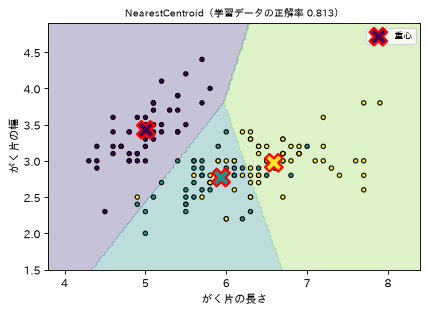

In [12]:
iris = load_iris()
X2, yi = iris.data[:, :2], iris.target
nc = nbr.NearestCentroid().fit(X2, yi)
fig, ax = plt.subplots(figsize=(6, 4))
plot_regions(ax, nc, X2, yi, f"NearestCentroid（学習データの正解率 {nc.score(X2, yi):.3f}）")
ax.scatter(nc.centroids_[:, 0], nc.centroids_[:, 1], marker="X", s=250, c=[0, 1, 2], cmap="viridis", edgecolor="red", lw=2, label="重心")
ax.set_xlabel("がく片の長さ"); ax.set_ylabel("がく片の幅"); ax.legend(fontsize=8); plt.show()

### 👀 結果の読み方

- 大きな × 印が各クラスの重心です。決定境界は、**2 つの重心を結ぶ線分の垂直二等分線**（どちらの重心からも同じ距離の線）で、すべて**直線**です。最近傍重心法は、実は**線形**の分類器です。
- 3 つの領域は、重心のまわりの「縄張り」（ボロノイ図）になっています。
- versicolor（緑）と virginica（黄）は重なっているので、どんな直線でもきれいには分けられません。

### 🧪 やってみよう: 苦手なデータ（ガイドの「凸でない」「分散が違う」）

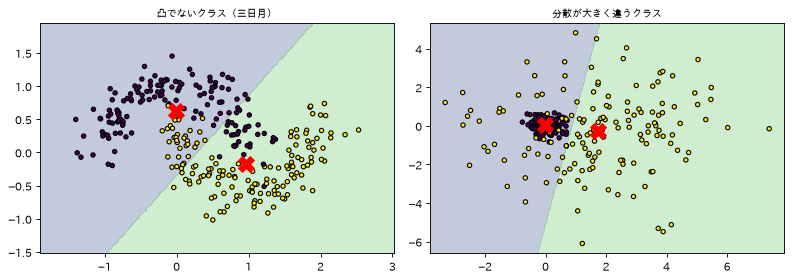

,三日月,分散が違う
交差検証の正解率,,
NearestCentroid,0.77,0.8433
KNeighborsClassifier(15),0.98,0.9300
QuadraticDiscriminantAnalysis,0.84,0.9633


In [13]:
Xm, ym = make_moons(300, noise=0.2, random_state=0)
rs = np.random.RandomState(0)
Xv = np.vstack([rs.randn(150, 2) * 0.3 + [0, 0], rs.randn(150, 2) * 2.0 + [2, 0]])   # 分散が大きく違う 2 クラス
yv = np.r_[np.zeros(150, int), np.ones(150, int)]
cv = StratifiedKFold(5, shuffle=True, random_state=0)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, (name, Xd, yd) in zip(axes, [("凸でないクラス（三日月）", Xm, ym), ("分散が大きく違うクラス", Xv, yv)]):
    m = nbr.NearestCentroid().fit(Xd, yd)
    plot_regions(ax, m, Xd, yd, name)
    ax.scatter(m.centroids_[:, 0], m.centroids_[:, 1], marker="X", s=200, c="red")
plt.tight_layout(); plt.show()
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
pd.DataFrame({name: {"NearestCentroid": cross_val_score(nbr.NearestCentroid(), Xd, yd, cv=cv).mean(),
                     "KNeighborsClassifier(15)": cross_val_score(nbr.KNeighborsClassifier(15), Xd, yd, cv=cv).mean(),
                     "QuadraticDiscriminantAnalysis": cross_val_score(QuadraticDiscriminantAnalysis(), Xd, yd, cv=cv).mean()}
              for name, Xd, yd in [("三日月", Xm, ym), ("分散が違う", Xv, yv)]}).rename_axis("交差検証の正解率")

### 👀 結果の読み方

- **三日月（左）**: 重心は三日月の「くぼみ」の近くに来てしまい、境界は 1 本の直線です。三日月の先端が相手の領域に入っています。曲がった境界が引ける k 近傍法のほうが、ずっと正解率が高くなりました。
- **分散が違う（右）**: 境界は 2 つの重心のちょうど中間の直線です。しかし、本当は「小さく固まったクラス 0 の、すぐ外側はもうクラス 1」なので、境界は小さな円になるべきです。最近傍重心法は「どのクラスも同じ広がり」と仮定しているので、広がったクラス 1 の点の多くを、クラス 0 の側に入れてしまいます。分散の違いをモデルに入れる QDA（1.2 節）が、この形を捉えられます。

### 1.6.5.1 縮小重心法（Nearest Shrunken Centroid）

#### 📖 ガイドの解説

`NearestCentroid` 分類器には `shrink_threshold` という引数があり、**縮小重心（nearest shrunken centroid）**分類器を実装しています。事実上、各重心の各特徴の値を、その特徴の**クラス内の分散**で割ります。その後、特徴の値を `shrink_threshold` だけ小さくします。最も重要なのは、ある特徴の値が **0 を越えたら、0 にする**ことです。事実上、これはその特徴が分類に影響しないようにします。これは、たとえば**ノイズの特徴を取り除く**のに役立ちます。

ガイドの例では、小さな縮小のしきい値を使うと、モデルの正解率が 0.81 から 0.82 に上がります。

> ⚠️ **ガイドの説明の補足（実装を読んで分かったこと）**: 実際に縮めるのは「重心の値そのもの」ではなく、「**全体の重心からのずれ**」を、クラス内の**標準偏差**（分散ではない）で割った値です。scikit-learn の実装は、次の式（*The Elements of Statistical Learning* の式 18.4〜18.5）に従っています。

### 💬 縮小重心（ことばで）

各クラスの重心が全体の重心から「**ばらつきに比べて、どれだけはっきりずれているか**」を特徴ごとに測り、そのずれを一律に `shrink_threshold` だけ小さくします。ずれがしきい値より小さい特徴は、ずれが 0（= どのクラスの重心も全体の重心と同じ）になり、その特徴は分類に使われなくなります。1.1 の Lasso の「ソフトしきい値」と同じ考え方です。

> 📐 式で確かめたい人へ: [数式編「縮小重心の式」](./math/06_neighbors_2_algorithms_nca_math.md#shrunken)

#### 🧪 式どおりに計算して、scikit-learn と比べる

（数式編と対応する実験です。とばしても先へ進めます）

In [14]:
delta = 0.2
nsc = nbr.NearestCentroid(shrink_threshold=delta).fit(X2, yi)
classes = np.unique(yi)
n, nk = len(yi), np.bincount(yi)
cent = np.array([X2[yi == c].mean(0) for c in classes])
overall = X2.mean(0)
s = np.sqrt(((X2 - cent[yi]) ** 2).sum(0) / (n - len(classes)))       # クラス内の標準偏差
s0 = np.median(s)
m_c = np.sqrt(1 / nk - 1 / n)[:, None]
d = (cent - overall) / (m_c * (s + s0))
d_shrunk = np.sign(d) * np.maximum(np.abs(d) - delta, 0)
my_centroids = overall + m_c * (s + s0) * d_shrunk
print("自分で計算した縮小重心:\n", my_centroids.round(4))
print("scikit-learn の centroids_:\n", nsc.centroids_.round(4))
print("一致:", np.allclose(my_centroids, nsc.centroids_))
print(f"\n学習データの正解率: 縮小なし {nbr.NearestCentroid().fit(X2, yi).score(X2, yi):.2f} → shrink_threshold=0.2 {nsc.score(X2, yi):.2f}")

自分で計算した縮小重心:
 [[5.0278 3.4103]
 [5.9142 2.7877]
 [6.5662 2.9917]]
scikit-learn の centroids_:
 [[5.0278 3.4103]
 [5.9142 2.7877]
 [6.5662 2.9917]]
一致: True

学習データの正解率: 縮小なし 0.81 → shrink_threshold=0.2 0.82


👀 式どおりの計算が `centroids_` と一致しました。正解率もガイドのとおり **0.81 → 0.82** です（ガイドの例と同じく、がく片の 2 特徴で、**学習データ**で測った値です）。ただし、0.01 の差は 150 件中の 1〜2 件の違いにすぎず、学習データで測っているので、「縮小で性能が上がった」と言うには根拠が弱い点に注意してください。

#### 🧪 縮小がノイズの特徴を取り除く様子

縮小が本領を発揮するのは、**役に立たない特徴がたくさんある**ときです。アヤメの 4 特徴に、ラベルと関係のない乱数の特徴を 50 個足し、しきい値を変えて、交差検証の正解率と「ずれが 0 でない（使われている）特徴の数」を調べます。

In [15]:
rs = np.random.RandomState(0)
Xn = np.hstack([iris.data, rs.randn(len(yi), 50)])        # 本物 4 個 + ノイズ 50 個
rows = []
for th in [None, 0.5, 1.0, 2.0, 4.0, 8.0]:
    m = nbr.NearestCentroid(shrink_threshold=th).fit(Xn, yi)
    used = (np.abs(m.deviations_) > 0).any(axis=0)          # どれかのクラスでずれが 0 でない特徴
    rows.append({"shrink_threshold": str(th), "交差検証の正解率": cross_val_score(nbr.NearestCentroid(shrink_threshold=th), Xn, yi, cv=cv).mean(),
                 "使われている本物の特徴": int(used[:4].sum()), "使われているノイズの特徴": int(used[4:].sum())})
pd.DataFrame(rows).set_index("shrink_threshold")

,交差検証の正解率,使われている本物の特徴,使われているノイズの特徴
shrink_threshold,,,
None,0.7933,4,50
0.5,0.9067,4,25
1.0,0.9333,4,5
2.0,0.8667,4,0
4.0,0.8267,3,0
8.0,0.7200,1,0


### 🏢 実務での選ばれ方: 最近傍重心法（`NearestCentroid`）

- ✅ **特に選ばれる場面**: 最も単純なベースライン。特徴が非常に多くサンプルが少ないデータ（遺伝子発現によるがんの分類、PAM）で、縮小版を使って特徴を絞りながら分類したいとき。テキスト分類の古典的な方法（Rocchio 分類）も同じ考え方です。
- ❌ **選ばれない場面**: クラスの形が凸でない・広がり方が違う（上の実験のとおり）→ k 近傍法、QDA、勾配ブースティングなど。
- 🔗 **実務でよくある組み合わせ・代わりの手法**: 「まず `NearestCentroid` とロジスティック回帰でベースラインを作り、より複雑なモデルと比べる」という使い方が基本です。深層学習の少数ショット学習（Prototypical Networks）は、埋め込みの空間での最近傍重心法そのものです。

### 👀 結果の読み方

- 縮小なし（`None`）では、ノイズの特徴 50 個がすべて距離に効いてしまい、正解率が下がっています。
- しきい値を上げると、ノイズの特徴のずれが次々に 0 になって「使われない」状態になり、正解率が上がっていきます（`1.0` でノイズの特徴は 5 個まで減り、正解率は最高）。本物の 4 特徴は、クラスによるずれが大きいので、しきい値 `2.0` までは残ります。
- しきい値をそれ以上に上げると、ノイズの特徴がすべて消えても正解率は下がり始め、`4.0` 以上では本物の特徴まで消えていきます。縮小は、重心どうしの差そのものも小さくするからです。しきい値も交差検証で選ぶのが確実です。

🕰️ **歴史（参考情報）**: 縮小重心法は、2002 年にティブシラニ（Tibshirani）らが、遺伝子の発現データ（数千の遺伝子 = 特徴に対して、患者 = サンプルが数十）でがんの種類を分類するために提案した方法です（PAM: Prediction Analysis for Microarrays）。「特徴が非常に多く、そのほとんどが無関係」という状況のために作られました。

---
## 3. 最近傍の Transformer（1.6.6 Nearest Neighbors Transformer）

### 📖 ガイドの解説

多くの scikit-learn の推定器は、最近傍に頼っています。`KNeighborsClassifier` や `KNeighborsRegressor` などの分類器・回帰器だけでなく、`DBSCAN` や `SpectralClustering` などのクラスタリング、`TSNE` や `Isomap` などの多様体への埋め込みもそうです。

これらの推定器はどれも、内部で最近傍を計算できますが、ほとんどは、`kneighbors_graph` や `radius_neighbors_graph` が返すような、**前もって計算した最近傍の疎なグラフ**も受け付けます。`mode='connectivity'` では、これらの関数は、たとえば `SpectralClustering` が必要とする、**0/1 の隣接の疎なグラフ**を返します。一方、`mode='distance'` では、たとえば `DBSCAN` が必要とする、**距離の疎なグラフ**を返します。これらの関数を scikit-learn のパイプラインに入れるには、対応するクラス `KNeighborsTransformer` と `RadiusNeighborsTransformer` を使えます。

In [16]:
Xr, _ = make_regression(n_samples=50, n_features=25, random_state=0)
for mode in ["connectivity", "distance"]:
    G = nbr.kneighbors_graph(Xr, n_neighbors=5, mode=mode)
    print(f"kneighbors_graph(mode={mode!r}): 形 {G.shape}, 1 行目の値 {G[0].data.round(2)}, 1 行目の列 {G[0].indices}")

kneighbors_graph(mode='connectivity'): 形 (50, 50), 1 行目の値 [1. 1. 1. 1. 1.], 1 行目の列 [37 27 41 42 10]
kneighbors_graph(mode='distance'): 形 (50, 50), 1 行目の値 [5.53 5.63 5.67 5.76 5.84], 1 行目の列 [37 27 41 42 10]


👀 `connectivity` は近傍の位置に 1 を、`distance` は近傍との距離を入れた疎行列です。どちらも各行に 5 個の値があります（関数 `kneighbors_graph` は、既定では**自分自身を含めません**）。

### 📖 疎なグラフの API の利点

この疎なグラフの API の利点はいくつもあります。

**1 つ目**: 前もって計算したグラフは、たとえば推定器の引数を変えながら、何度も**使い回せます**。これはユーザーが手で行うこともできますし、scikit-learn のパイプラインの**キャッシュ**の機能を使うこともできます（ガイドの例）。

In [17]:
cache_path = tempfile.mkdtemp()                     # 一時的なフォルダを使う
estimator = make_pipeline(
    nbr.KNeighborsTransformer(mode="distance"),
    Isomap(n_components=3, metric="precomputed"),
    memory=cache_path)
X_embedded = estimator.fit_transform(Xr)
X_embedded.shape

(50, 3)

👀 ガイドと同じく `(50, 3)` です。`memory=cache_path` を指定したパイプラインは、`KNeighborsTransformer` の結果（近傍グラフ）をディスクに保存し、同じデータと引数なら、2 回目からは計算せずに読み込みます。

#### 🧪 グリッドサーチで近傍グラフを使い回す（ガイドの例 *Caching nearest neighbors* の考え方）

`n_neighbors` を変えながら k 近傍法を調べるとき、毎回近傍を探し直すのは無駄です。一番大きな $k$ で近傍グラフを 1 回だけ作り、分類器には `metric="precomputed"` でそれを渡します。

In [18]:
Xd, yd = load_digits(return_X_y=True)
ks = [1, 3, 5, 9, 15]
graph_pipe = Pipeline([("graph", nbr.KNeighborsTransformer(n_neighbors=max(ks), mode="distance")),
                       ("knn", nbr.KNeighborsClassifier(metric="precomputed"))], memory=tempfile.mkdtemp())
plain_pipe = Pipeline([("knn", nbr.KNeighborsClassifier())])
cv5 = StratifiedKFold(5, shuffle=True, random_state=0)
res = {}
for name, pipe in [("近傍グラフを使い回す", graph_pipe), ("毎回近傍を探す", plain_pipe)]:
    t = time.perf_counter()
    gs = GridSearchCV(pipe, {"knn__n_neighbors": ks}, cv=cv5).fit(Xd, yd)
    res[name] = {"時間（秒）": time.perf_counter() - t, "選ばれた k": gs.best_params_["knn__n_neighbors"],
                 **{f"k={k}": s for k, s in zip(ks, gs.cv_results_["mean_test_score"])}}
pd.DataFrame(res).T

,時間（秒）,選ばれた k,k=1,k=3,k=5,k=9,k=15
近傍グラフを使い回す,0.2901,3.0,0.9878,0.9878,0.9855,0.9850,0.9783
毎回近傍を探す,0.1071,3.0,0.9878,0.9878,0.9855,0.9844,0.9783


### 👀 結果の読み方

- 2 つの方法で、各 $k$ の交差検証の正解率は**ほぼ同じ**です。$k = 9$ だけ 0.0006（1,797 件中 1 件）違いますが、調べると、その 1 件では 9 番目と 10 番目の近傍が**同じ距離で違うラベル**でした。Digits の特徴は整数値なので同じ距離が起こりやすく、2 つの方法で同じ距離の点の並び順が違ったため、1/2 の ⚠️（ガイドの警告）と同じことが起きています。それ以外は結果が変わりません。
- 時間は、この小さなデータ（1,797 件）では、キャッシュの読み書きのぶん、使い回すほうが**遅く**なりました。使い回しが効いてくるのは、近傍の探索が重い大きなデータや、調べる引数の組み合わせが多いときです。

**2 つ目**: グラフを前もって計算すると、最近傍の推定をより細かく制御できます。たとえば、すべての推定器にあるとは限らない引数 `n_jobs` で、**並列処理**ができます。

**最後に**: 前もっての計算を独自の推定器で行えば、**近似最近傍**の方法や、特殊なデータ型での実装など、異なる実装を使えます。前もって計算した近傍の疎なグラフは、`radius_neighbors_graph` の出力と同じ形式にする必要があります。

- CSR 行列（COO、CSC、LIL も受け付ける）
- 各サンプルの、学習データに対する最近傍だけを明示的に保存する。問い合わせ点から距離 0 のものも含める。学習データとそれ自身の最近傍を計算するときは、**行列の対角**も含める
- 各行のデータは、距離の小さい順に並べて保存する（任意。並んでいないデータは安定ソートされ、計算のオーバーヘッドが増える）
- データの値はすべて非負
- どの行にも、重複した列の添字がない（scipy/scipy#5807 を参照）
- 前もって計算した行列を渡すアルゴリズムが、（半径の近傍ではなく）$k$ 個の最近傍を使う場合、各行に少なくとも $k$ 個の近傍を保存する（あるいは、次の注で説明するように $k+1$ 個）

> 📚 **用語**: **近似最近傍（approximate nearest neighbors, ANN）** — 厳密な最近傍をあきらめる代わりに、桁違いに速く「ほぼ最近傍」を見つける方法。数億件のベクトルを検索するベクトル検索エンジン（Faiss、Annoy、HNSW など）の中心技術。

### 📖 注: `n_neighbors` の定義のあいまいさ

決まった数の近傍を問い合わせるとき（`KNeighborsTransformer` を使うとき）、`n_neighbors` の定義はあいまいです。各学習点を**自分自身の近傍として数える**こともできれば、**数えない**こともできるからです。どちらの選択も完璧ではありません。含めると、学習とテストで自分以外の近傍の数が変わり、除くと、`fit(X).transform(X)` と `fit_transform(X)` が違う結果になり、scikit-learn の API に反します。

`KNeighborsTransformer` では、各学習点を `n_neighbors` の数の中に**自分自身の近傍として含める**定義を使っています。ただし、もう一方の定義を使うほかの推定器との互換性のため、`mode == 'distance'` のときは、近傍を**1 つ余分に**計算します。すべての推定器との互換性を最大にするには、独自の最近傍の推定器では、常に近傍を 1 つ余分に含めるのが安全な選択です。不要な近傍は、後に続く推定器が取り除きます。

In [19]:
for mode in ["connectivity", "distance"]:
    G = nbr.KNeighborsTransformer(n_neighbors=5, mode=mode).fit_transform(Xr)
    print(f"KNeighborsTransformer(n_neighbors=5, mode={mode!r}): 各行の値の数 {np.unique(G.getnnz(axis=1))}, "
          f"1 行目の値 {G[0].data.round(2)}, 対角を含む: {G[0, 0] != 0 or 0 in G[0].indices}")

KNeighborsTransformer(n_neighbors=5, mode='connectivity'): 各行の値の数 [5], 1 行目の値 [1. 1. 1. 1. 1.], 対角を含む: True
KNeighborsTransformer(n_neighbors=5, mode='distance'): 各行の値の数 [6], 1 行目の値 [0.   5.53 5.63 5.67 5.76 5.84], 対角を含む: True


### 🏢 実務での選ばれ方: 近傍グラフの使い回し（`KNeighborsTransformer`）

- ✅ **特に選ばれる場面**: 同じデータで近傍を何度も使うとき（`n_neighbors` のグリッドサーチ、複数のアルゴリズムで同じ近傍グラフを使い回す）。近似最近傍のライブラリを scikit-learn のパイプラインに組み込みたいとき。
- ❌ **選ばれない場面**: データが小さいとき（使い回しの効果より、キャッシュの手間のほうが大きい。上の実験のとおり）。
- 🔗 **実務でよくある組み合わせ・代わりの手法**: 大規模な t-SNE / UMAP / DBSCAN の前処理として、近似最近傍のライブラリ（pynndescent、Annoy など）で近傍グラフを作って渡す使い方が実務的です（ガイドの例 *Approximate nearest neighbors in TSNE*）。

👀 `n_neighbors=5` なのに、`mode="distance"` では各行に **6 個**の値があり、先頭は距離 0（自分自身）です。`mode="connectivity"` では 5 個（自分自身を含む）です。注の説明どおりで、`"distance"` のグラフを `KNeighborsClassifier(n_neighbors=5, metric="precomputed")` などに渡すと、後ろの推定器が自分自身の扱いを決めて、必要な分を使います。

> ⚠️ **つまずきポイント（ガイドに書かれていない）**: 関数 `kneighbors_graph` と、クラス `KNeighborsTransformer` では、**同じ `n_neighbors=5` でも中身が違います**。関数は自分自身を含めずに 5 個（上のセル）、クラスの `"distance"` は自分自身 + 5 個 = 6 個です。前もって計算したグラフを自分で作るときは、どちらの定義になっているかを確かめましょう。

---
## 4. 近傍成分分析（1.6.7 Neighborhood Components Analysis）

### 📖 ガイドの解説

近傍成分分析（NCA、`NeighborhoodComponentsAnalysis`）は、**距離の学習（distance metric learning）**のアルゴリズムで、標準的なユークリッド距離に比べて、最近傍分類の正解率を高めることを目指します。このアルゴリズムは、学習データ上の **leave-one-out の k 近傍法のスコア**の確率的な変種を、直接最大化します。また、データの可視化や高速な分類に使える、**低次元への線形の射影**を学習することもできます。

> 📚 **用語**
> - **距離の学習（metric learning）** — 「どの点とどの点を近いとみなすか」を、データから学習すること。1/2 で見たように、k 近傍法の性能は距離の選び方で大きく変わるので、距離そのものを学習してしまおう、という発想。
> - **leave-one-out** — 1 つのサンプルを除いて残りで予測し、それを全サンプルについて繰り返す評価（交差検証の、分割数 = サンプル数の場合）。
> - **射影（projection）** — データに行列を掛けて、別の（多くは低次元の）空間に移すこと。

💡 **たとえ話**: 定規の目盛りを特徴ごとに伸び縮みさせたり、斜めに傾けたりできる「ゴムの定規」を想像してください。NCA は、「同じクラスの点どうしが近く、違うクラスの点どうしが遠くに見える」ように、このゴムの定規の伸ばし方（行列 $L$）を学習します。

#### 📈 ガイドの図の再現: 確率的な近傍

ガイドの図（*Neighborhood Components Analysis Illustration* の例）は、ランダムに作ったデータの点 3 に注目しています。点 3 と別の点を結ぶ線の太さは、確率的な最近傍の規則がその点に割り当てる**相対的な重み（確率）**に比例します（ガイドの本文には「距離に比例」とありますが、図を描いている例のコードでは、線の太さに softmax の確率 $p_{3j}$ を使っていて、**近い点ほど太く**なります）。元の空間では、点 3 はさまざまなクラスの確率的な近傍を持っているので、正しいクラスになる確率は高くありません。しかし NCA で学習した射影の空間では、重みが無視できない確率的な近傍は点 3 と同じクラスのものだけなので、点 3 は正しく分類されることが保証されます。

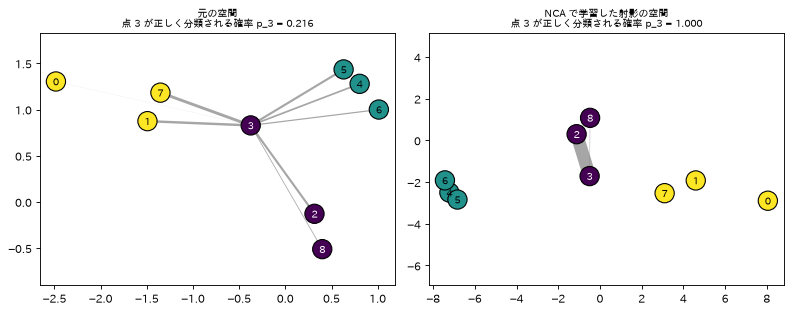

In [20]:
Xs, ys = make_classification(n_samples=9, n_features=2, n_informative=2, n_redundant=0, n_classes=3,
                             n_clusters_per_class=1, class_sep=1.0, random_state=0)
i_focus = 3

def stochastic_neighbors(Z, i):
    d2 = ((Z[i] - Z) ** 2).sum(1); d2[i] = np.inf
    p = np.exp(-d2 - np.max(-d2)); return p / p.sum()          # p_ij（softmax、p_ii = 0）

nca_s = nbr.NeighborhoodComponentsAnalysis(max_iter=30, random_state=0).fit(Xs, ys)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (title, Z) in zip(axes, [("元の空間", Xs), ("NCA で学習した射影の空間", nca_s.transform(Xs))]):
    p = stochastic_neighbors(Z, i_focus)
    for j in range(len(Z)):
        if j != i_focus:
            ax.plot(*zip(Z[i_focus], Z[j]), c="gray", lw=12 * p[j], alpha=0.7, zorder=1)
    ax.scatter(Z[:, 0], Z[:, 1], c=ys, cmap="viridis", s=300, edgecolor="k", zorder=2)
    for j, (a, b) in enumerate(Z):
        ax.text(a, b, str(j), ha="center", va="center", color="white" if ys[j] == 0 else "k", fontsize=9, zorder=3)
    p_correct = p[ys == ys[i_focus]].sum()
    ax.set_title(f"{title}\n点 3 が正しく分類される確率 p_3 = {p_correct:.3f}", fontsize=9); ax.grid(False)
    ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout(); plt.show()

### 👀 結果の読み方

- 線の太さが、点 3 から見た各点の「近傍に選ばれる確率」$p_{3j}$ です。
- **元の空間（左）**では、点 3 のまわりに違うクラス（違う色）の点もあり、それらにも太い線が伸びています。点 3 が正しく分類される確率 $p_3$（同じ色の点への確率の合計）は、図のタイトルの値です。
- **NCA の空間（右）**では、同じクラスの点が集まり、太い線は同じ色の点にだけ伸びています。$p_3$ は 1 に近くなりました。

### 1.6.7.1 分類

#### 📖 ガイドの解説

最近傍の分類器（`KNeighborsClassifier`）と組み合わせると、NCA は分類に魅力的です。モデルの大きさを増やさずに多クラスの問題を自然に扱え、ユーザーが細かく調整すべき追加のパラメータも導入しないからです。

NCA による分類は、さまざまな大きさと難しさのデータで、実際によく働くことが示されています。線形判別分析などの関連する方法とは対照的に、NCA は**クラスの分布について何も仮定しません**。最近傍の分類は、自然に非常に不規則な決定境界を作れます。

この分類のモデルを使うには、最適な変換を学習する `NeighborhoodComponentsAnalysis` のインスタンスと、射影された空間で分類する `KNeighborsClassifier` のインスタンスを組み合わせます。2 つのクラスを使った例です（ガイドの例）。

In [21]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.7, random_state=42)
nca = nbr.NeighborhoodComponentsAnalysis(random_state=42)
knn = nbr.KNeighborsClassifier(n_neighbors=3)
nca_pipe = Pipeline([("nca", nca), ("knn", knn)])
nca_pipe.fit(X_train, y_train)
print("NCA + k 近傍法       :", nca_pipe.score(X_test, y_test))
print("k 近傍法だけ（比較用）:", nbr.KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train).score(X_test, y_test))

NCA + k 近傍法       : 0.9619047619047619
k 近傍法だけ（比較用）: 0.9333333333333333


👀 ガイドと同じ 0.9619 です。比較のため、NCA なしの k 近傍法も測ると、それより低い値でした。学習データが 45 件（`test_size=0.7`）と少ないなかで、NCA の距離が効いています。

#### 📈 学習したモデルを見る: k 近傍法と NCA + k 近傍法の決定境界

ガイドの図と同じく、見やすさのためにアヤメの 2 特徴だけで学習し、決定境界を比べます（ガイドの例 *Comparing Nearest Neighbors with and without Neighborhood Components Analysis* と同じく `n_neighbors=1`、標準化あり）。

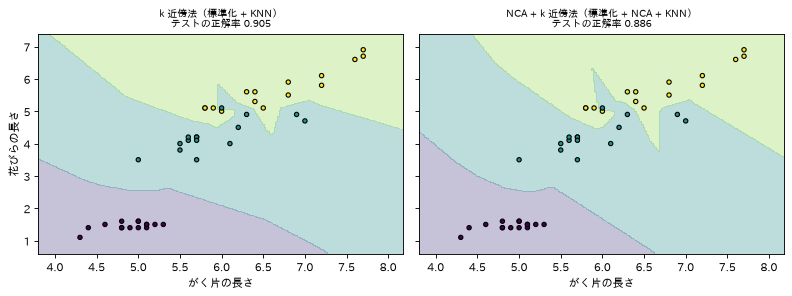

In [22]:
X2 = iris.data[:, [0, 2]]                        # がく片の長さ・花びらの長さ
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, yi, stratify=yi, test_size=0.7, random_state=42)
models = {"k 近傍法（標準化 + KNN）": make_pipeline(StandardScaler(), nbr.KNeighborsClassifier(n_neighbors=1)),
          "NCA + k 近傍法（標準化 + NCA + KNN）": make_pipeline(StandardScaler(), nbr.NeighborhoodComponentsAnalysis(random_state=42), nbr.KNeighborsClassifier(n_neighbors=1))}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, (name, m) in zip(axes, models.items()):
    m.fit(X2_tr, y2_tr)
    plot_regions(ax, m, X2_tr, y2_tr, f"{name}\nテストの正解率 {m.score(X2_te, y2_te):.3f}")
    ax.set_xlabel("がく片の長さ")
axes[0].set_ylabel("花びらの長さ"); plt.tight_layout(); plt.show()

### 👀 結果の読み方

- どちらも $k = 1$ なので、境界は学習データの点に沿った不規則な形になります（「最近傍の分類は非常に不規則な決定境界を作れる」）。
- NCA を入れると、境界の形が変わります。NCA で学習した距離では、「近い」とみなされる点の組が変わるからです。たとえば setosa（紫）の領域の境目の傾きが変わっています。
- この分割（ガイドの例と同じ `random_state=42`）では、テストの正解率は NCA を入れたほうが**わずかに低く**なりました（105 件中 2 件の差）。NCA が最大化するのは、**学習データ（45 件）**での確率的な正解率なので、学習データが少ないと、テストで必ずよくなるとは限りません。1 回の分割の結果だけでは判断できないので、分割を 20 通り変えて比べます。

In [23]:
rows = []
for seed in range(20):
    a_tr, a_te, b_tr, b_te = train_test_split(X2, yi, stratify=yi, test_size=0.7, random_state=seed)
    rows.append({name: m.fit(a_tr, b_tr).score(a_te, b_te) for name, m in models.items()})
df_seed = pd.DataFrame(rows)
print("20 通りの分割での平均:\n", df_seed.mean().round(3).to_string())
print("NCA を入れたほうが高かった回数:", (df_seed.iloc[:, 1] > df_seed.iloc[:, 0]).sum(),
      "/ 低かった回数:", (df_seed.iloc[:, 1] < df_seed.iloc[:, 0]).sum(), "/ 同じ:", (df_seed.iloc[:, 1] == df_seed.iloc[:, 0]).sum())

20 通りの分割での平均:
 k 近傍法（標準化 + KNN）                0.91
NCA + k 近傍法（標準化 + NCA + KNN）    0.93
NCA を入れたほうが高かった回数: 15 / 低かった回数: 2 / 同じ: 3


👀 20 通りの分割で平均すると、NCA を入れたほうが正解率が高く、NCA が上回った回数のほうがずっと多くなりました。ガイドの例と同じ `random_state=42` の分割は、たまたま NCA が下回る数少ない分割の 1 つでした。**1 回の分割の結果で手法の良し悪しを決めない**ことが大切です（交差検証、3.1 節）。

### 1.6.7.2 次元削減

#### 📖 ガイドの解説

NCA は、**教師ありの次元削減**に使えます。入力のデータは、NCA の目的関数を最小化する方向からなる線形の部分空間に射影されます。目的の次元は、引数 `n_components` で指定できます。たとえば次の図は、$n_{samples} = 1797$、$n_{features} = 64$ の Digits データで、主成分分析（PCA）、線形判別分析（`LinearDiscriminantAnalysis`）、近傍成分分析（`NeighborhoodComponentsAnalysis`）による次元削減を比べたものです。データを同じ大きさの学習データとテストデータに分け、標準化します。評価には、それぞれの方法で見つけた **2 次元**に射影した点で、3-最近傍法の正解率を計算します。各サンプルは 10 クラスのどれかに属します。

#### 📈 ガイドの図の再現: Digits を 2 次元に

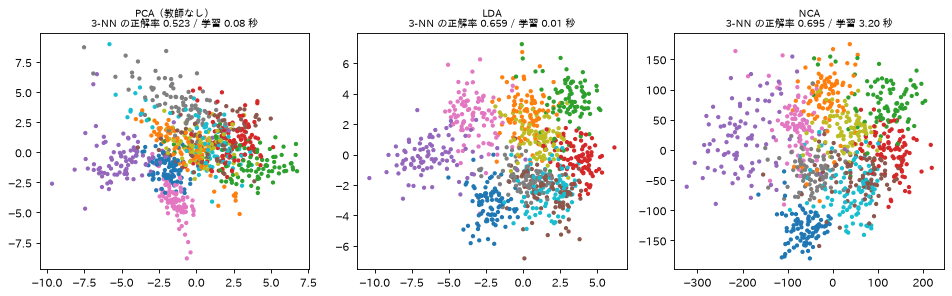

In [24]:
Xd, yd = load_digits(return_X_y=True)
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.5, stratify=yd, random_state=0)
reducers = {"PCA（教師なし）": PCA(n_components=2, random_state=0),
            "LDA": LinearDiscriminantAnalysis(n_components=2),
            "NCA": nbr.NeighborhoodComponentsAnalysis(n_components=2, random_state=0)}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (name, red) in zip(axes, reducers.items()):
    t = time.perf_counter()
    pipe = make_pipeline(StandardScaler(), red).fit(Xd_tr, yd_tr)
    elapsed = time.perf_counter() - t
    knn3 = nbr.KNeighborsClassifier(n_neighbors=3).fit(pipe.transform(Xd_tr), yd_tr)
    Zte = pipe.transform(Xd_te)
    acc = knn3.score(Zte, yd_te)
    ax.scatter(Zte[:, 0], Zte[:, 1], c=yd_te, cmap="tab10", s=8)
    ax.set_title(f"{name}\n3-NN の正解率 {acc:.3f} / 学習 {elapsed:.2f} 秒", fontsize=9); ax.grid(False)
plt.tight_layout(); plt.show()

### 👀 結果の読み方

- 色が数字のクラス（0〜9）です。**PCA** はラベルを使わず「ばらつきが最大の方向」を選ぶので、クラスがかなり混ざっています。
- **LDA** はラベルを使って、クラスの平均が離れる方向を選ぶので、PCA よりまとまります。
- **NCA** は、「その 2 次元で k 近傍法がうまくいく」ことを直接目的にしているので、3-NN の正解率が 3 つの中で最も高くなりました。ただし、学習には PCA や LDA より大幅に時間がかかります（最適化を繰り返すため）。
- 64 次元を 2 次元に落としているので、どの方法でも正解率はそれほど高くありません。次元を 2 にしたのは、図にするためです。

### 1.6.7.3 しくみ（式は数式編）

NCA は、データに掛ける変換（行列 `components_`）を学習します。目的は、「変換した空間で、各点が**くじ引きで近傍を 1 つ選ぶ**と、同じクラスの点を引く確率」の合計を最大にすることです。くじは、近い点ほど当たりやすくなっています（softmax、1.1 の 3/4）。

💬 **ことばで言うと**: 各点がくじ引きで近傍を 1 つ選ぶ。近い点ほど当たりやすい。同じクラスの点を引けば正解。全点の正解の確率の合計が最大になるように、空間の伸ばし方を決める。

> 📐 式で確かめたい人へ: [数式編「NCA の目的関数」](./math/06_neighbors_2_algorithms_nca_math.md#nca)

💡 普通の k 近傍法の leave-one-out の正解率は、「一番近い点がどれか」で 0 か 1 に飛ぶので、$L$ を少し動かしても変わらないか、急に変わるかのどちらかで、微分できません。NCA は「近傍をくじで選ぶ」と考えることで、**なめらかな（微分できる）**目的関数にして、勾配を使った最適化を可能にしています。ガイドの「確率的な変種」はこの意味です。

#### 🧪 目的関数を自分で計算する

（数式編と対応する実験です。とばしても先へ進めます）アヤメの 4 特徴で、変換なしの場合と、NCA が学習した変換の場合で、「正解の確率の合計」を計算します。最大値はサンプル数の 150 です。

In [25]:
def nca_objective(L, X, y):
    Z = X @ L.T
    d2 = ((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1)
    np.fill_diagonal(d2, np.inf)                            # p_ii = 0
    P = np.exp(-(d2 - d2.min(1, keepdims=True)))            # 数値の安定のため、各行の最小値を引いてから exp
    P /= P.sum(1, keepdims=True)
    return (P * (y[:, None] == y[None, :])).sum()            # Σ_i Σ_{j∈C_i} p_ij

X, y = load_iris(return_X_y=True)
nca_full = nbr.NeighborhoodComponentsAnalysis(random_state=42).fit(X, y)
print("変換なし（L = 単位行列）の Σ p_i:", round(nca_objective(np.eye(4), X, y), 2), "/ 150")
print("NCA が学習した L の Σ p_i      :", round(nca_objective(nca_full.components_, X, y), 2), "/ 150")
print("components_ の形:", nca_full.components_.shape, "/ 反復回数 n_iter_:", nca_full.n_iter_)

変換なし（L = 単位行列）の Σ p_i: 125.71 / 150
NCA が学習した L の Σ p_i      : 148.0 / 150
components_ の形: (4, 4) / 反復回数 n_iter_: 19


👀 NCA で学習した変換では、正解の確率の合計が 150 に近づきました。「ほとんどの点が、くじ引きでほぼ確実に同じクラスの点を引く」空間になっています。

### 📖 マハラノビス距離

NCA は、**マハラノビス距離**（1.2 で見た、データの広がり方で目盛りを変えた距離）を学習していると見ることもできます。「変換してから普通の定規で距離を測る」のと、「変換せずに、伸び縮みする特別な定規で距離を測る」のは同じことだからです。

💬 **ことばで言うと**: その特別な定規（行列 M）は、特徴ごとの伸び縮みと、特徴どうしの組み合わせ（斜めの方向）の伸び縮みを表す。

> 📐 式で確かめたい人へ: [数式編「マハラノビス距離としての NCA」](./math/06_neighbors_2_algorithms_nca_math.md#mahalanobis)

> 📚 **用語**: **マハラノビス距離** — インドの統計学者マハラノビス（P. C. Mahalanobis）が 1936 年に導入した距離。もともとは定規の行列に共分散行列の逆行列を使い、「ばらつきの大きい方向の差は小さく見る」距離。NCA では定規の行列をデータから学習する。

#### 🧪 2 つの計算が同じになることを確かめる

（数式編と対応する実験です。とばしても先へ進めます）

In [26]:
L = nca_full.components_
M = L.T @ L
xi, xj = X[0], X[60]
print("‖L(x_i - x_j)‖²          :", round(float(np.sum((L @ (xi - xj)) ** 2)), 4))
print("(x_i - x_j)ᵀ M (x_i - x_j):", round(float((xi - xj) @ M @ (xi - xj)), 4))
print("M は対称:", np.allclose(M, M.T), "/ M の固有値:", np.linalg.eigvalsh(M).round(2))

‖L(x_i - x_j)‖²          : 24340.0438
(x_i - x_j)ᵀ M (x_i - x_j): 24340.0438
M は対称: True / M の固有値: [   0.9     2.51  325.26 5103.07]


### 🏢 実務での選ばれ方: NCA（`NeighborhoodComponentsAnalysis`）

- ✅ **特に選ばれる場面**: k 近傍法の精度を、距離を学習して上げたいとき（特徴が数十個くらい、データが数千件まで）。クラスの分かれ方を 2 次元で見たいとき（教師ありの可視化）。
- ❌ **選ばれない場面**: データが数万件を超える（学習でサンプル数の 2 乗のメモリが要る）。曲がった変換が必要な画像・文章など。
- 🔗 **実務でよくある組み合わせ・代わりの手法**: 実務では、距離の学習は深層学習の埋め込み（Siamese ネットワーク、Triplet 損失、対照学習）が主流になっています。表形式のデータでは、NCA より「標準化 + 特徴選択 + k 近傍法」や、勾配ブースティングが選ばれることが多いです。

👀 2 つの計算（変換してから測る / 特別な定規で測る）の値が一致しました。定規の行列 M は対称で、固有値（伸び縮みの大きさ）はすべて 0 以上です。固有値の大きさは大きく違い、NCA が**ある方向を大きく引き伸ばし、別の方向をほとんど縮めて**いることが分かります。

> 💡 NCA の変換には、全体の大きさ（スケール）を決める仕組みがないので、学習した変換は、元の距離をかなり大きく引き伸ばしていることがあります。距離が大きいほど softmax が「一番近い点」に集中し、確率的な k 近傍法が普通の 1-最近傍法に近づくからです。

### 1.6.7.4 実装

この実装は、元の論文 [1] の説明に従っています。最適化の方法には、現在、scipy の **L-BFGS-B** を、各反復で勾配を全部計算して使っています。学習率の調整を不要にし、安定した学習にするためです。詳しくは、ガイドの例と `NeighborhoodComponentsAnalysis.fit` のドキュメントを参照してください。

> 📚 **用語**: **L-BFGS-B** — 勾配の情報から、2 次の情報（曲がり具合）を近似して使う最適化の方法（1.1 の 3/4 の `lbfgs` ソルバと同じ系統）。B は変数の範囲の制約（bounds）に対応していることを表す。SGD（1.5 節）と違い、学習率を決めなくてよい。

### 1.6.7.5 計算量

#### 1.6.7.5.1 学習

NCA は点の組の距離の行列を保存するので、`n_samples ** 2` のメモリを使います。時間の計算量は、最適化のアルゴリズムの反復回数に依存します。ただし、引数 `max_iter` で反復の最大回数を設定できます。各反復の時間の計算量は `O(n_components x n_samples x min(n_samples, n_features))` です。

#### 1.6.7.5.2 変換

`transform` は学習した行列をデータに掛けるだけ（式では $L X^T$）なので、時間の計算量は `n_components * n_features * n_samples_test` に等しくなります。この操作で追加の空間の計算量はありません。

💡 つまり、NCA は**学習が重く**（サンプル数の 2 乗のメモリ）、**変換は軽い**（行列を掛けるだけ）方法です。数万件を超えるデータでは、学習データを間引いて NCA を学習し、変換だけを全データに使う、といった工夫が必要になります。

🕰️ **歴史（参考情報）**: NCA は、2004 年の NeurIPS（当時の NIPS、論文集は 2005 年）で、ゴールドバーガー（J. Goldberger）、ロウェイス（S. Roweis）、ヒントン（G. Hinton）、サラクディノフ（R. Salakhutdinov）が発表しました。「k 近傍法の性能そのものを、微分できる形にして最適化する」という発想は、その後の距離の学習（LMNN など）や、ニューラルネットワークで埋め込みを学習する方法（深層距離学習）にもつながっています。

---
## 5. まとめ

### 近傍探索のアルゴリズム

| | 総当たり（`brute`） | KD Tree（`kd_tree`） | Ball Tree（`ball_tree`） |
|---|---|---|---|
| 分け方 | 分けない | 軸に平行な箱 | 入れ子の球 |
| 1 回の問い合わせ | $O[DN]$ | 小さな $D$ で約 $O[D \log N]$、大きな $D$ でほぼ $O[DN]$ | 約 $O[D \log N]$（データの構造しだい） |
| 構築 | 不要 | 速い | KD Tree より遅い |
| 得意 | 小さな $N$、高次元、大きな $k$、少ない問い合わせ、疎な入力 | 低次元（$D \lesssim 15$） | 構造のあるデータ、多くの距離（haversine など） |
| この実験では | 高次元では最速（行列の積が速い） | 3 次元・大きな $N$ で速い | 高次元では KD Tree より速い |

### このノートのクラス

| クラス | 何をするか | 覚えておくこと |
|---|---|---|
| `KDTree` / `BallTree` | 近傍探索の索引 | `leaf_size=30` がよい妥協点。`get_arrays()` で中身を見られる |
| `NearestCentroid` | 一番近い重心のクラスに分類 | 線形の境界。凸でない・分散が違うクラスに弱い。`shrink_threshold` でノイズの特徴を消せる |
| `KNeighborsTransformer` | 近傍グラフを作る Transformer | `mode="distance"` では自分自身 + `n_neighbors` 個 |
| `NeighborhoodComponentsAnalysis` | k 近傍法のための線形変換（距離）を学習 | 学習は $n^2$ のメモリ。教師ありの次元削減にも使える |

### 覚えておきたい 3 つのこと

1. **木構造は「計算しなくてよい距離」を見つける索引**。低次元・構造のあるデータで強く、高次元・構造のないデータでは総当たりに負ける。`auto` の規則（$D > 15$ なら総当たり など）はその経験則。
2. **最近傍重心法は「重心だけ覚える」最も単純な分類器**で、よいベースライン。縮小版は、特徴が多くノイズが多いデータで、使う特徴を自動で絞る。
3. **NCA は「k 近傍法がうまくいく距離」を学習する**。確率的な近傍（softmax）で微分できる目的関数にし、マハラノビス距離 $M = L^T L$ を学習していると見なせる。

### 🧩 ドメインモデルの視点

- `NearestNeighbors` の `algorithm` 引数は、**同じインターフェース（`query`）を持つ複数の索引の実装**から 1 つを選ぶ**ストラテジーパターン**です。`auto` は、データの性質（次元、疎か、距離の種類）から実装を選ぶ**ファクトリ**の役割で、その判断規則がガイドに明記されている（= 公開された契約）のが特徴です。一方、選ばれた結果の `_fit_method` は非公開で、利用者が依存してよい契約ではありません。
- `KNeighborsTransformer` + `metric="precomputed"` は、「近傍を探す」責務と「近傍を使って予測する」責務を**分離**する設計です。分離したことで、キャッシュ（`memory`）、並列化、近似最近傍の実装への差し替えが、予測側を変えずにできるようになりました。ただし、「`n_neighbors` に自分自身を含むか」という**境界の定義**が両者で食い違いうることが、注で説明されていた問題の本質です。境界を越えて受け渡すデータ（疎なグラフ）の形式を、ガイドが細かく規定しているのはそのためです。
- `NeighborhoodComponentsAnalysis` は、Transformer（`fit` / `transform`）として作られているので、`Pipeline` で k 近傍法の前に置くだけで「距離を学習する k 近傍法」になります。「距離の学習」と「分類」を 1 つのクラスにせず、**組み合わせ可能な部品**にしているので、次元削減だけに使うこともできます。

### ✅ 確認クイズ

**Q1.** 特徴が 100 個の一様なデータで、`algorithm="kd_tree"` を指定したら、`algorithm="brute"` より何十倍も遅くなりました。なぜですか。

<details><summary>答え</summary>

次元の呪いのためです。高次元では、どの点もだいたい同じくらい遠いので、「この箱の中の点はどれも遠い」と判断して枝を刈ることがほとんどできず、ほぼすべての点との距離を計算することになります。そのうえ木をたどるオーバーヘッドが加わるので、行列の積でまとめて計算できる総当たりより遅くなります。`algorithm="auto"` なら、$D > 15$ では総当たりが選ばれます。
</details>

**Q2.** Ball Tree で、問い合わせ点とノードの中心の距離が 10、ノードの半径が 3、今の候補の最近傍までの距離が 5 です。このノードの中の点との距離を計算する必要はありますか。

<details><summary>答え</summary>

ありません。三角不等式から、ノードの中のどの点との距離も $10 - 3 = 7$ 以上です。今の候補（距離 5）より近い点はないので、ノードごと枝刈りできます。
</details>

**Q3.** `NearestCentroid` の決定境界は、どんな形になりますか。それはなぜですか。

<details><summary>答え</summary>

直線（高次元では超平面）です。2 つの重心 $\mu_a$, $\mu_b$ から等距離の点の集まり（$\lVert x - \mu_a \rVert^2 = \lVert x - \mu_b \rVert^2$）は、展開すると $x$ の 2 乗の項が消えて $x$ の 1 次式になるので、2 つの重心を結ぶ線分の垂直二等分線（超平面）になるからです。
</details>

**Q4.** `KNeighborsTransformer(n_neighbors=5, mode="distance")` の出力は、各行にいくつの値を持ちますか。

<details><summary>答え</summary>

6 個です。自分自身（距離 0）を近傍に含める定義で 5 個に加え、自分自身を数えない定義の推定器との互換性のために、1 つ余分に計算します。
</details>

**Q5.** NCA が普通の leave-one-out の k 近傍法の正解率ではなく、確率的な近傍の正解率 $\sum_i p_i$ を最大化するのはなぜですか。

<details><summary>答え</summary>

普通の k 近傍法の正解率は、「どの点が一番近いか」で 0 か 1 に飛ぶ、なめらかでない（微分できない）関数なので、勾配を使った最適化ができないからです。近傍を softmax の確率で選ぶと考えると、目的関数が $L$ についてなめらかになり、L-BFGS-B などで最適化できます。
</details>

---
**前のノート**: [1.6 最近傍法（1/2）近傍の探索・分類・回帰](./06_neighbors_1_knn.ipynb) ・ **次の節**: 1.7 ガウス過程（準備中）